Now that I have selected the templates I will find the thresholds.

In [ ]:
from pathlib import Path

from calibration_calcs import (
    compute_auc,
    compute_roc_curve,
    dtw_cross_costs,
    find_threshold_youden_from_roc,
    plot_dtw_scatter,
    plot_roc_curve,
    save_threshold_new_pr
)
from stft import resample_audio
from feature import load_features_from_json, make_stft_extractor

import numpy as np
import matplotlib.pyplot as plt

#Path to get templates
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

#Path to get calib_templates
DATA_26 = Path(r"C:\Users\HP\Desktop\Skripsie data\26")
RESULTS_26 = DATA_26 / "template_selections"

#Path to store thresholds
RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")
THRESHOLDS = RESULTS / "Thresholds"

#Number of templates
file_name = "5_Templates"
n_temps = 5
n_calib = 10

#Type of feature extraction method
extractor = make_stft_extractor()    

In [2]:
def find_threshold_best_f1(call_costs, background_costs, n_thresholds=200, beta=1.0):
    """
    Sweep thresholds and return the one maximizing F-beta score,
    treating call_costs as positives (cost <= threshold => detected as call).
    """
    call_costs = np.array(call_costs)
    background_costs = np.array(background_costs)

    lo = min(call_costs.min(), background_costs.min())
    hi = max(call_costs.max(), background_costs.max())
    thresholds = np.linspace(lo, hi, n_thresholds)

    best_score, best_t = -1, thresholds[0]
    for t in thresholds:
        tp = np.sum(call_costs <= t)
        fp = np.sum(background_costs <= t)
        fn = np.sum(call_costs > t)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        if precision + recall == 0:
            f_score = 0
        else:
            f_score = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)

        if f_score > best_score:
            best_score, best_t = f_score, t

    return best_t, best_score

In [3]:
def compute_pr_curve_from_costs(call_costs, background_costs, n_thresholds=200):
    """
    Compute precision/recall at each threshold, sweeping over the cost range.
    Mirrors compute_roc_curve's structure but returns precision/recall instead of fpr/tpr.
    """
    call_costs = np.array(call_costs)
    background_costs = np.array(background_costs)

    lo = min(call_costs.min(), background_costs.min())
    hi = max(call_costs.max(), background_costs.max())
    thresholds = np.linspace(lo, hi, n_thresholds)

    precision, recall = [], []
    for t in thresholds:
        tp = np.sum(call_costs <= t)
        fn = np.sum(call_costs > t)
        fp = np.sum(background_costs <= t)

        precision.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
        recall.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

    return np.array(precision), np.array(recall), thresholds

In [4]:
def find_threshold_best_f1_from_pr(precision, recall, thresholds, beta=1.0):
    """Given precision/recall/thresholds (from compute_pr_curve_from_costs), find the best F-beta point."""
    with np.errstate(divide="ignore", invalid="ignore"):
        f_scores = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)
    f_scores = np.nan_to_num(f_scores, nan=0.0)

    best_idx = np.argmax(f_scores)
    return thresholds[best_idx], f_scores[best_idx]

In [5]:
def plot_pr_curve_from_costs(call_costs, background_costs, n_thresholds=200,
                              best_threshold=None, ax=None):
    precision, recall, thresholds = compute_pr_curve_from_costs(call_costs, background_costs, n_thresholds)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot(recall, precision, color="tab:blue", linewidth=2, label="PR curve")

    if best_threshold is not None:
        idx = np.argmin(np.abs(thresholds - best_threshold))
        ax.scatter(recall[idx], precision[idx], color="red", zorder=5,
                   label=f"Chosen threshold = {best_threshold:.3f}")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve: DTW-based Call Detection")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)

    if standalone:
        plt.show()

    return precision, recall, thresholds

In [ ]:
def load_template_features_fixed_length(entry, extractor, window_len, fs_new=1000):
    """
    Like load_segment_features, but centers/pads the segment to exactly
    window_len seconds instead of using the call's own start/end duration.
    """
    with sf.SoundFile(entry["wav_path"]) as f:
        f_s = f.samplerate
        call_start, call_end = entry["start_time"], entry["end_time"]
        call_center = (call_start + call_end) / 2

        half_len = window_len / 2
        seg_start = max(0.0, call_center - half_len)
        seg_end = seg_start + window_len

        start_sample = int(seg_start * f_s)
        end_sample = int(seg_end * f_s)
        f.seek(start_sample)
        segment = f.read(end_sample - start_sample, dtype="int16")

    audio = resample_audio(segment, f_s, fs_new)

    target_len = int(fs_new * window_len)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)), mode="constant")
    elif len(audio) > target_len:
        audio = audio[:target_len]

    return extractor(audio, fs_new)

[single_tone] Threshold: 0.1396 (F1 = 0.9796)


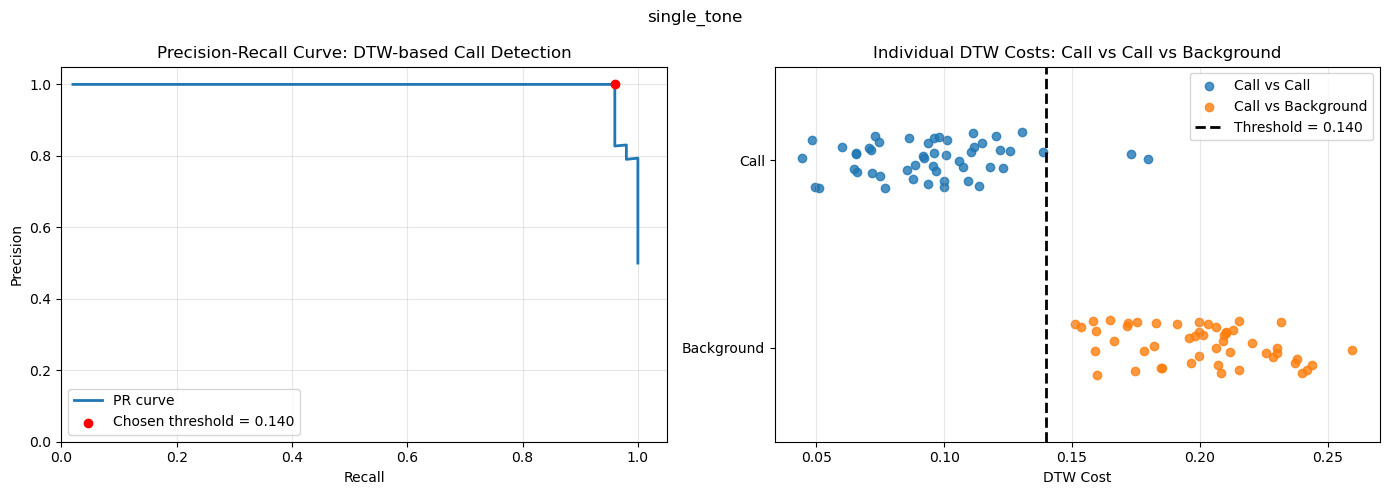

Saved threshold for 'single_tone' [stft] to 5_Templates_stft_single_tone_threshold.json: threshold=0.1396, f1=0.9796
[multi_tone] Threshold: 0.1571 (F1 = 0.8352)


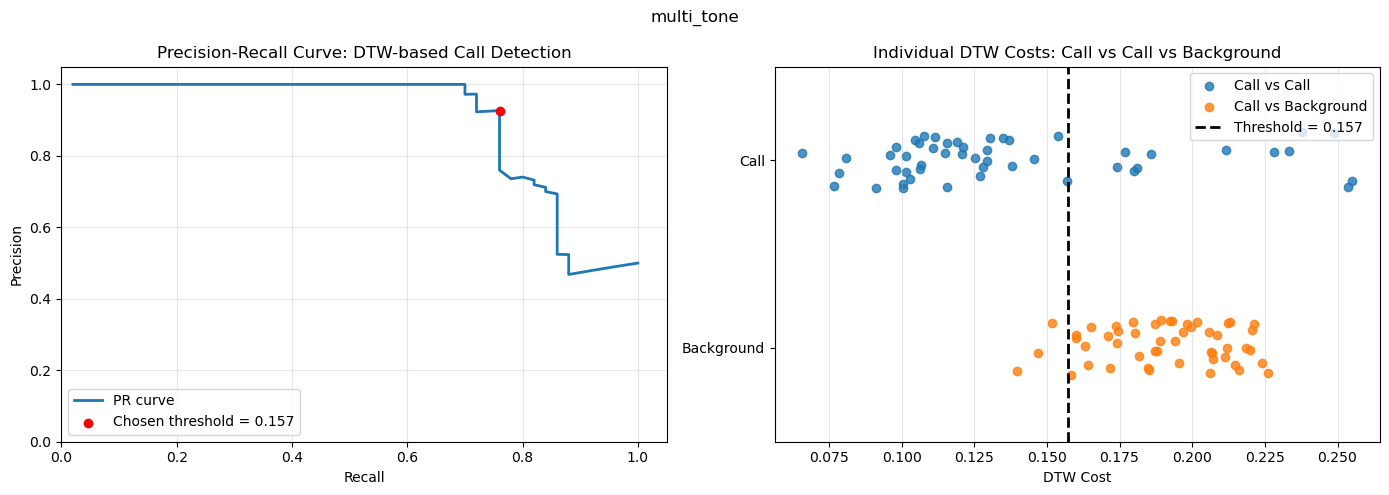

Saved threshold for 'multi_tone' [stft] to 5_Templates_stft_multi_tone_threshold.json: threshold=0.1571, f1=0.8352
[burst_tonal] Threshold: 0.1467 (F1 = 0.9362)


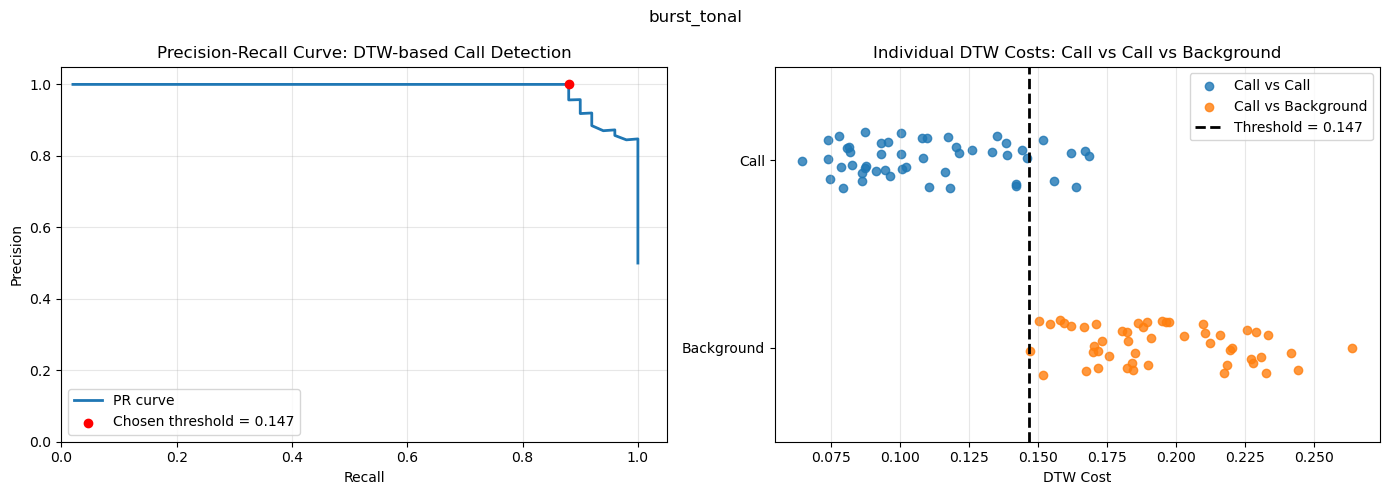

Saved threshold for 'burst_tonal' [stft] to 5_Templates_stft_burst_tonal_threshold.json: threshold=0.1467, f1=0.9362


In [6]:
''' Calculate thresholds and ROC curve for each call type and save the values in seperated . json files
    Plot results
'''


#start of filename where templates are stored
TEMPLATE_filename_start = "20230429_Templates_20230429_102841"

#Create item() for call type file_names
#"call_type" : "calib_file"
CALIB_FILES = {
    "single_tone": "ST_CALIB_26_20230426_075505_single_tone_templates.json",
    "multi_tone":  "MT_CALIB_26_20230426_075505_multi_tone_templates.json",
    "burst_tonal": "BT_CALIB_26_20230426_075505_burst_tonal_templates.json",
}

bg_file = "Bground_CALIB_26_20230426_075505_background.json"

#Load in background templates 
bg_features = load_features_from_json(RESULTS_26 / bg_file, extractor, n_calib)

#loop through each of three call types
for call_type, calib_file in CALIB_FILES.items():
    template_features = load_features_from_json(RESULTS_29 / f"{TEMPLATE_filename_start}_{call_type}_templates.json", extractor, n_temps)
    calib_features = load_features_from_json(RESULTS_26 / calib_file, extractor, n_calib)

    call_costs = dtw_cross_costs(template_features, calib_features, extractor.metric)
    bg_costs = dtw_cross_costs(template_features, bg_features, extractor.metric)

    # --- PR / F1 based threshold ---
    precision, recall, pr_thresholds = compute_pr_curve_from_costs(call_costs, bg_costs)
    threshold, f1 = find_threshold_best_f1_from_pr(precision, recall, pr_thresholds)
    print(f"[{call_type}] Threshold: {threshold:.4f} (F1 = {f1:.4f})")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_pr_curve_from_costs(call_costs, bg_costs, best_threshold=threshold, ax=axes[0])
    plot_dtw_scatter(call_costs, bg_costs, threshold=threshold, ax=axes[1])
    fig.suptitle(f"{call_type}")
    plt.tight_layout()
    plt.show()

    save_threshold_new_pr(threshold, f1, call_type=call_type,
               score_name="f1",
               file_label=file_name, results_dir=THRESHOLDS,
               n_templates=n_temps, n_background=n_calib,
               feature_name=extractor.name, feature_params=extractor.params)